In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
from math import sqrt, pi, exp, comb
from tools import load, pseudoderivative

In [3]:
def _phi(x):
    return (1.0 / sqrt(2.0 * pi)) * exp(-0.5 * x * x)


def K(r, s, n_terms=30):
    if not (0.0 < s < 1.0):
        raise ValueError('s must be in (0,1).')
    r = float(min(max(r, np.nextafter(-1.0, 0.0)), np.nextafter(1.0, 0.0)))
    d = 1.0 - s
    t = float(norm.ppf(s))
    phi_t = _phi(t)
    a_prev, a_curr = d, phi_t
    rn_nfact = 1.0
    result = rn_nfact * a_prev * a_prev
    for n in range(1, n_terms + 1):
        rn_nfact *= r / n
        result += rn_nfact * a_curr * a_curr
        a_prev, a_curr = a_curr, t * a_curr - (n - 1) * a_prev
    return result / d

In [4]:
# --- Parameters (matching gs_single_152) ---
n_hd = 10000
k = 500
s = 1 - k / n_hd
n_train = 450
filename = '1_600_20'

# --- Load and expand to 152 traces ---
sensor_data, sequence, times_sec, sequence_sec = load(filename, reduced=True)
h = np.median(np.diff(times_sec))
n_sensors = sensor_data.shape[1]


def backward_diff_array(y, h, n):
    coeffs = np.array([(-1)**k * comb(n, k) for k in range(n + 1)])
    raw = np.convolve(y, coeffs, mode='valid') / h**n
    return np.concatenate([np.zeros(n), raw])


def expand_with_derivatives(data, h, max_order):
    if max_order == 0:
        return data.copy()
    derivs = []
    for order in range(1, max_order + 1):
        d = np.apply_along_axis(
            lambda col: backward_diff_array(col, h, order), axis=0, arr=data)
        derivs.append(d)
    return np.hstack([data] + derivs)


rng_pairs = np.random.default_rng(0)
all_ordered_pairs = [(i, j) for i in range(n_sensors)
                     for j in range(n_sensors) if i != j]
ratio_pairs = [all_ordered_pairs[i]
               for i in rng_pairs.permutation(len(all_ordered_pairs))]
diff_pairs = [all_ordered_pairs[i]
              for i in rng_pairs.permutation(len(all_ordered_pairs))]

x_d12 = expand_with_derivatives(sensor_data, h, max_order=2)  # 24 cols
r64 = np.column_stack([sensor_data[:, i] / (sensor_data[:, j] + 1e-8)
                       for i, j in ratio_pairs[:64]])
d64 = np.column_stack([sensor_data[:, i] - sensor_data[:, j]
                       for i, j in diff_pairs[:64]])
expanded_data = np.hstack([x_d12, d64, r64])  # 152 traces

# --- Labels (frame-level, training portion only) ---
labels = np.zeros_like(times_sec)
for i in range(len(sequence_sec[:n_train])):
    try:
        flag = (times_sec > sequence_sec[i]) & (times_sec < sequence_sec[i + 1])
    except IndexError:
        flag = (times_sec > sequence_sec[i])
    labels[flag] = int(sequence[i][1])

idx_first_flag = np.where(labels != 0)[0][0]

# --- Normalize and project ---
x_dense = expanded_data.copy()
row_norms = np.linalg.norm(x_dense, axis=1, keepdims=True)
x_dense = x_dense / row_norms
n_dense = x_dense.shape[1]

W_hd = np.random.binomial(n=1, p=0.25, size=(n_hd, n_dense))
x_hd = x_dense @ W_hd.T
ranks = np.argsort(np.argsort(-x_hd, axis=1), axis=1)
z_hd = np.where(ranks < k, 1., 0.)

# Restrict to labeled region
x_dense = x_dense[idx_first_flag:]
z_hd = z_hd[idx_first_flag:]
labels_region = labels[idx_first_flag:]

print(f'Expanded data: {expanded_data.shape[1]} traces')
print(f'Labeled frames in region: {np.sum(labels_region != 0)}')

Expanded data: 136 traces
Labeled frames in region: 8541


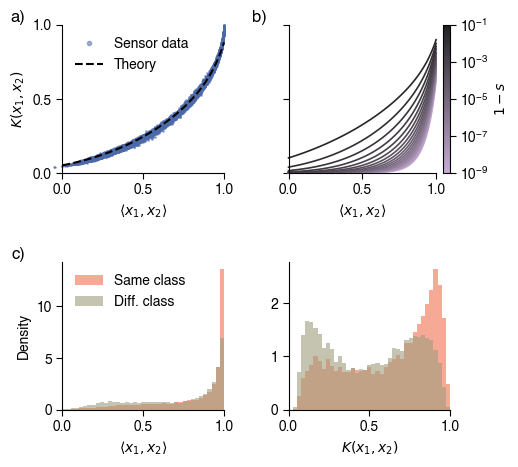

In [11]:
from matplotlib.colors import LinearSegmentedColormap, LogNorm, ListedColormap
from matplotlib.cm import ScalarMappable

rng = np.random.default_rng(42)
n_pairs = 10000
n_hist_pairs = 10000

# --- Top-left: kernel scatter (all random pairs) ---
x_scatter, y_scatter = [], []
for _ in range(n_pairs):
    idx1, idx2 = rng.choice(z_hd.shape[0], size=2, replace=False)
    x_scatter.append(np.dot(x_dense[idx1], x_dense[idx2]))
    y_scatter.append(np.dot(z_hd[idx1], z_hd[idx2]) / k)

# --- Histogram data by class (for bottom row) ---
labeled_idx = np.where(labels_region != 0)[0]
labeled_labels = labels_region[labeled_idx]

# Same-class pairs
same_ips_dense, same_ips_hd = [], []
while len(same_ips_dense) < n_hist_pairs:
    i1, i2 = rng.choice(len(labeled_idx), size=2, replace=False)
    if labeled_labels[i1] == labeled_labels[i2]:
        a, b = labeled_idx[i1], labeled_idx[i2]
        same_ips_dense.append(np.dot(x_dense[a], x_dense[b]))
        same_ips_hd.append(np.dot(z_hd[a], z_hd[b]) / k)

# Different-class pairs
diff_ips_dense, diff_ips_hd = [], []
while len(diff_ips_dense) < n_hist_pairs:
    i1, i2 = rng.choice(len(labeled_idx), size=2, replace=False)
    if labeled_labels[i1] != labeled_labels[i2]:
        a, b = labeled_idx[i1], labeled_idx[i2]
        diff_ips_dense.append(np.dot(x_dense[a], x_dense[b]))
        diff_ips_hd.append(np.dot(z_hd[a], z_hd[b]) / k)

same_ips_dense = np.array(same_ips_dense)
diff_ips_dense = np.array(diff_ips_dense)
same_ips_hd = np.array(same_ips_hd)
diff_ips_hd = np.array(diff_ips_hd)

# --- Theory curve ---
rs = np.arange(0, 1.01, 0.01)
vals = [K(r=ri, s=s) for ri in rs]

# --- Kernel shape curves (top-right) ---
cm = ListedColormap(plt.rcParams['axes.prop_cycle'].by_key()['color'])
graded_cmap = LinearSegmentedColormap.from_list(
    'red_to_dark', [cm.colors[3], cm.colors[4]], N=100)
density = np.logspace(-9, -1, 20)
norma = LogNorm(vmin=density.min(), vmax=density.max())
sm = ScalarMappable(norm=norma, cmap=graded_cmap)

# --- Plot (2x2) ---
fig, ax = plt.subplots(2, 2, figsize=(5, 5),
                       gridspec_kw={'wspace': 0.4, 'hspace': 0.6})

# Top-left (a): kernel scatter
ax0 = ax[0, 0]
ax0.plot(x_scatter, y_scatter, '.', alpha=0.5, ms=2, clip_on=False,
         label='Sensor data')
ax0.plot(rs, vals, '--', color='black', linewidth=1.5, clip_on=False,
         label='Theory')
ax0.set_ylabel(r'$K({x}_{1}, {x}_{2})$')
ax0.set_xlabel(r'$\langle {x}_{1}, {x}_{2} \rangle $')
ax0.legend(loc='upper left', frameon=False, fontsize=10, markerscale=3.)
ax0.set_xlim(0, 1)
ax0.set_ylim(0, 1)
ax0.set_xticks([0, 0.5, 1])
ax0.set_yticks([0, 0.5, 1])

# Top-right (b): kernel shape vs sparsity
ax1 = ax[0, 1]
for i, d in enumerate(density):
    s_i = 1 - d
    v = [K(r=ri, s=s_i) for ri in rs]
    ax1.plot(rs, v, color=graded_cmap(int((100. / len(density)) * i)),
             clip_on=False)

cbar = fig.colorbar(sm, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label('$1-s$')
cbar.set_ticks([1e-9, 1e-7, 1e-5, 1e-3, 1e-1])

ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_xticks([0, 0.5, 1])
ax1.set_yticks([0, 0.5, 1], labels=[])
ax1.set_xlabel(r'$\langle {x}_{1}, {x}_{2} \rangle $')

# Bottom-left (c): x_dense histograms
ax2 = ax[1, 0]
bins_dense = np.linspace(0, 1, 40)
ax2.hist(same_ips_dense, bins=bins_dense, alpha=0.6, color='C1',
         label='Same class', density=True, rasterized=True)
ax2.hist(diff_ips_dense, bins=bins_dense, alpha=0.6, color='C2',
         label='Diff. class', density=True, rasterized=True)
ax2.set_xlabel(r'$\langle {x}_{1}, {x}_{2} \rangle $')
ax2.set_ylabel('Density')
ax2.legend(loc='upper left', frameon=False, fontsize=10)
ax2.set_xlim(0, 1)
ax2.set_xticks([0, 0.5, 1])

# Bottom-right (d): z_hd histograms
ax3 = ax[1, 1]
bins_hd = np.linspace(0, 1, 40)
ax3.hist(same_ips_hd, bins=bins_hd, alpha=0.6, color='C1',
         label='Same class', density=True, rasterized=True)
ax3.hist(diff_ips_hd, bins=bins_hd, alpha=0.6, color='C2',
         label='Diff. class', density=True, rasterized=True)
ax3.set_xlabel(r'$K({x}_{1}, {x}_{2})$')
# ax3.set_ylabel('Density')
# ax3.legend(frameon=False, fontsize=9)
ax3.set_xlim(0, 1)
ax3.set_xticks([0, 0.5, 1])

# Labels
ax0.text(-0.23, 1., 'a)', transform=ax0.transAxes,
         fontsize=12, ha='right', va='bottom')
ax1.text(-0.15, 1., 'b)', transform=ax1.transAxes,
         fontsize=12, ha='right', va='bottom')
ax2.text(-0.23, 1., 'c)', transform=ax2.transAxes,
         fontsize=12, ha='right', va='bottom')
# ax3.text(-0.15, 1., 'd)', transform=ax3.transAxes,
         # fontsize=12, ha='right', va='bottom')

plt.savefig('figs/kernel_shape_classes.pdf', bbox_inches='tight')
plt.savefig('figs/kernel_shape_classes.png', bbox_inches='tight', dpi=300)
plt.show()